<a href="https://colab.research.google.com/github/kukanmani06/Internship_Projects/blob/main/Decision_Tree_%26_Random_Forest_Churn_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

2.Read Dataset

In [ ]:
telecom_df = pd.read_csv('https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/churn-bigml-80.csv')


In [ ]:
telecom_df.shape

(2666, 20)

In [ ]:
telecom_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

3.Is there any missing value

In [ ]:
telecom_df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [ ]:
telecom_df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


4.Label Encoding

In [ ]:
import sklearn.preprocessing
le = sklearn.preprocessing.LabelEncoder()
le.fit(telecom_df['International plan'])

LabelEncoder()

In [ ]:
telecom_df['International plan'] = le.transform(telecom_df['International plan'])

In [ ]:
telecom_df['Voice mail plan'] = le.fit_transform(telecom_df['Voice mail plan'])

5.Is there any multi-collinearity

In [ ]:
telecom_df.drop('State',axis =1 ,inplace=True)

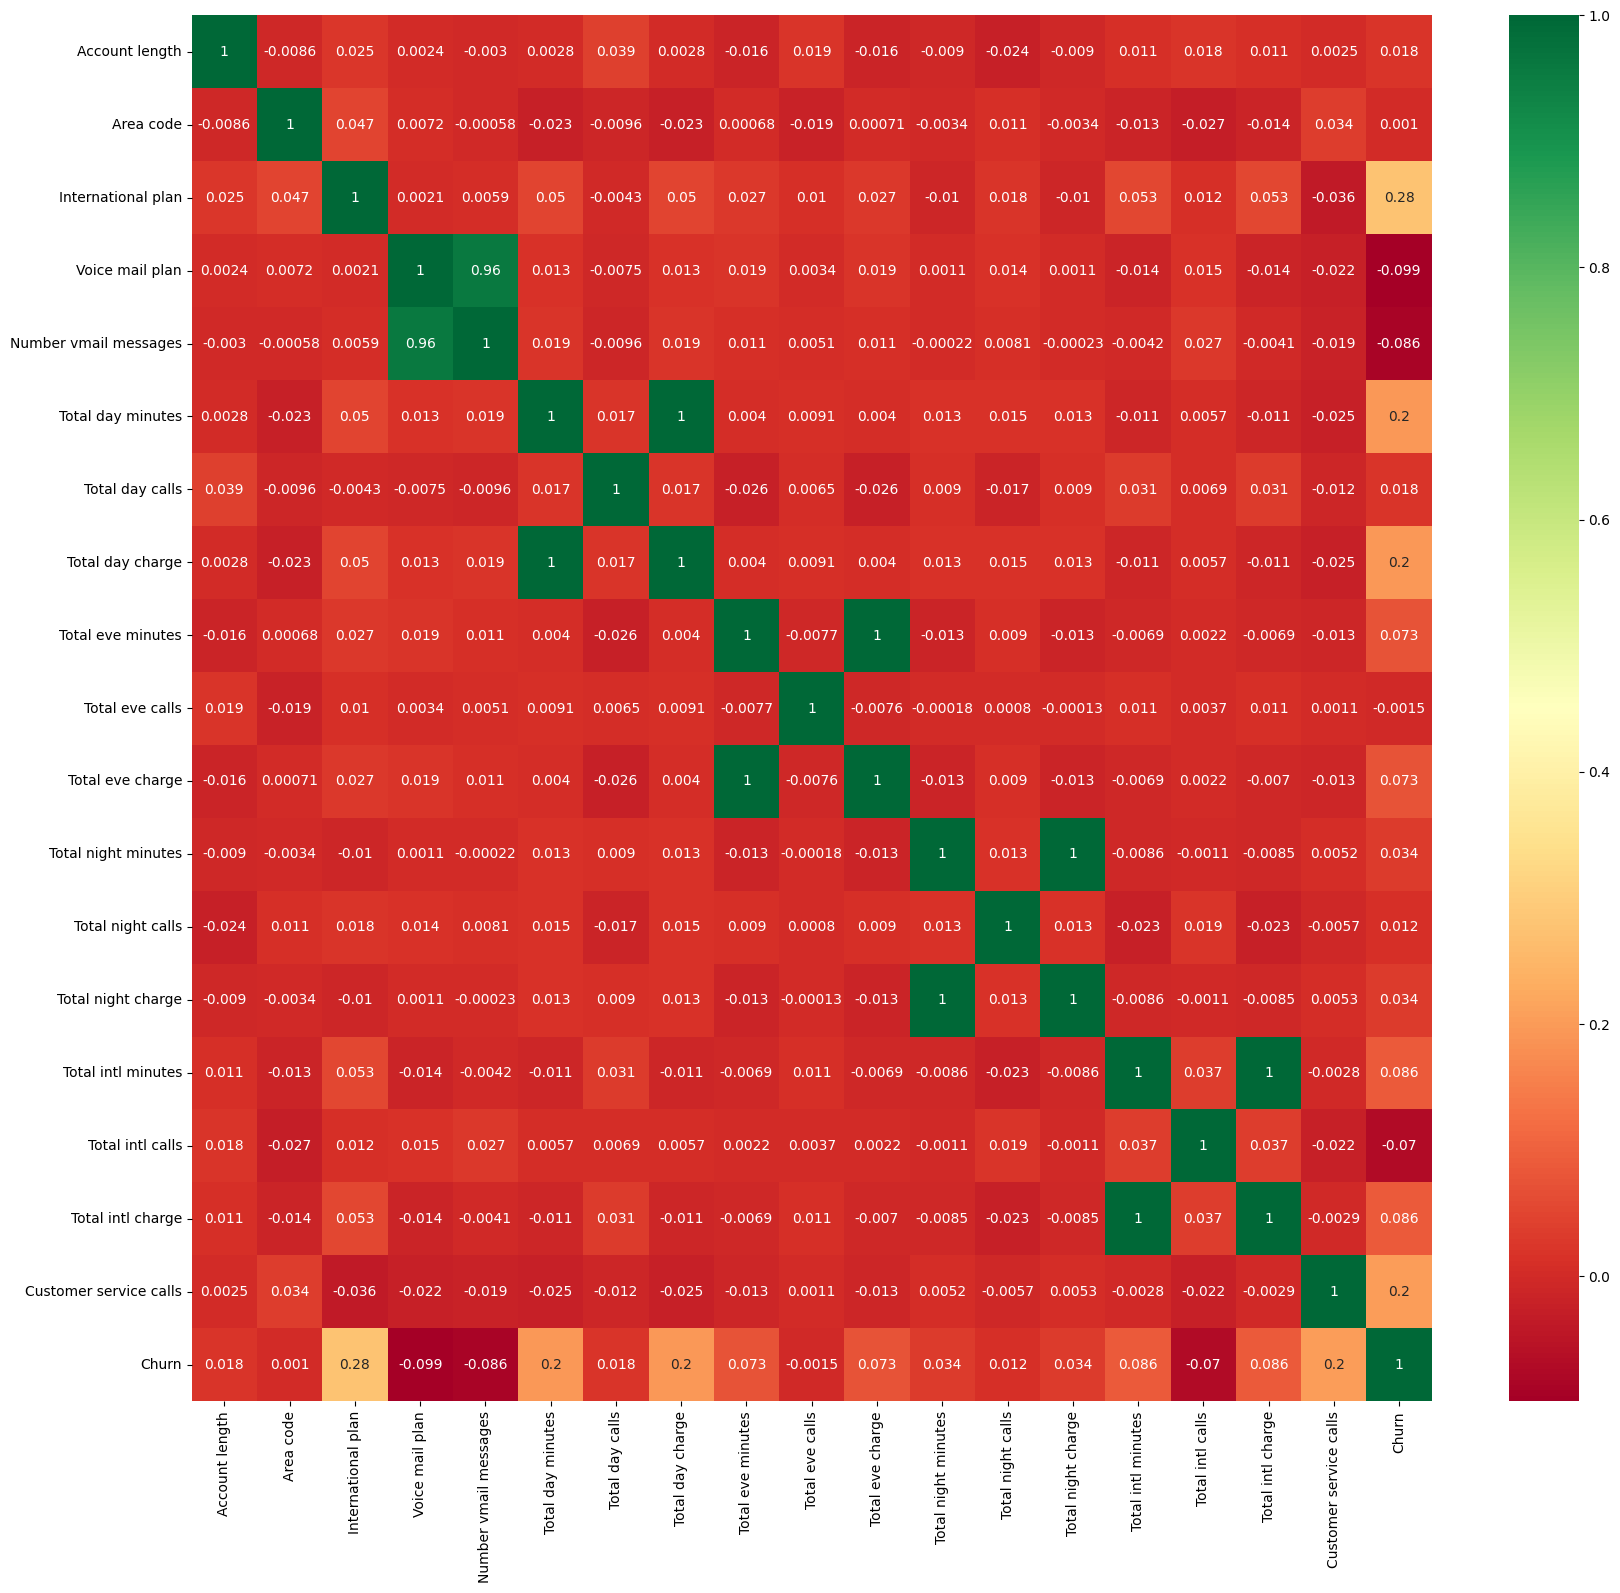

In [ ]:
plt.figure(figsize=(20,18))
sns.heatmap(telecom_df.corr(),annot=True,cmap = 'RdYlGn')
plt.show()

In [ ]:
telecom_df.columns

Index(['Account length', 'Area code', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')

6.Features & Labels

In [ ]:
X=telecom_df.drop(['Account length','Voice mail plan','Total day charge','Total eve charge','Total night charge','Total intl charge','Churn'],axis=1)
y=telecom_df['Churn']

7.Is there Imbalanced Class Label

In [ ]:
churn = telecom_df['Churn'].value_counts()


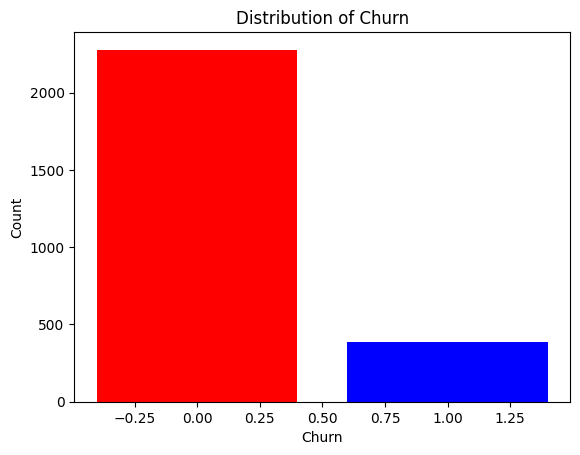

In [ ]:
plt.bar(churn.index,churn.values,color = ['red','blue'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

8.Upsample Data using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
transformed_feature, transformed_label = smote.fit_resample(X, y)

In [ ]:
transformed_label.value_counts()

,count
Churn,
False,2278
True,2278


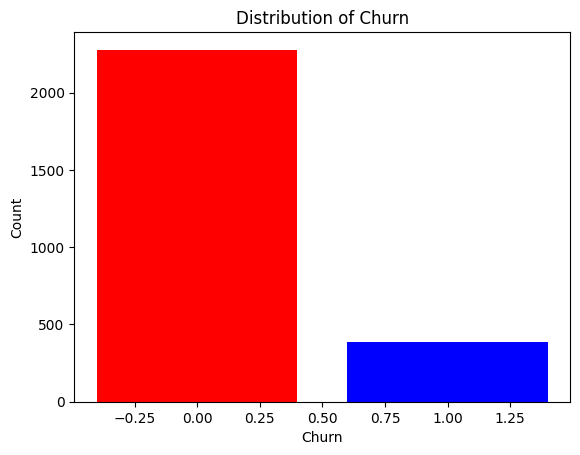

In [ ]:
plt.bar(churn.index,churn.values,color = ['red','blue'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

9.Split into train & test sample

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(transformed_feature,transformed_label,test_size=0.2,random_state=3)

In [ ]:
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=11, random_state=2)
clf_tree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=11, random_state=2)

In [ ]:
clf_tree.score(x_train,y_train)

0.9281009879253568

In [ ]:
clf_tree.get_depth()

11

11.Tree Visualization

In [ ]:
import graphviz
from sklearn import tree

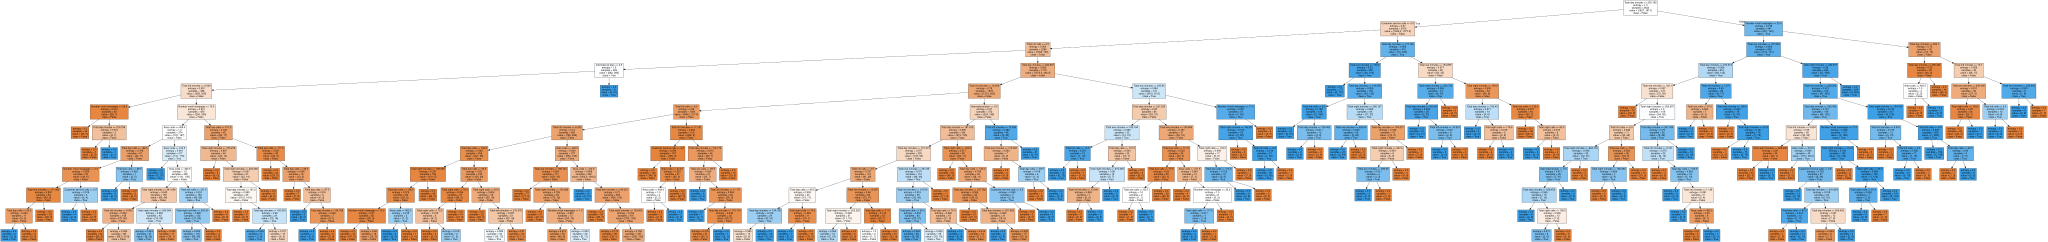

In [ ]:
dot_data = tree.export_graphviz(clf_tree,feature_names=x_train.columns,class_names=transformed_label.unique().astype('str'),filled=True)
graph = graphviz.Source(dot_data, format="png")
graph

Classification Metrics

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y_pred = clf_tree.predict(x_test)

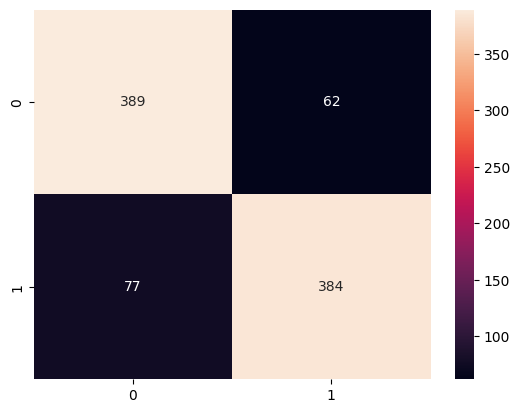

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.86      0.85       451
        True       0.86      0.83      0.85       461

    accuracy                           0.85       912
   macro avg       0.85      0.85      0.85       912
weighted avg       0.85      0.85      0.85       912



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
clf_rf = RandomForestClassifier(bootstrap = True,n_estimators = 50,max_features='sqrt',criterion='entropy',max_depth=11)
clf_rf.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=11, n_estimators=50)

In [ ]:
clf_rf.score(x_test,y_test)

0.8925438596491229

In [ ]:
y_pred = clf_rf.predict(x_test)

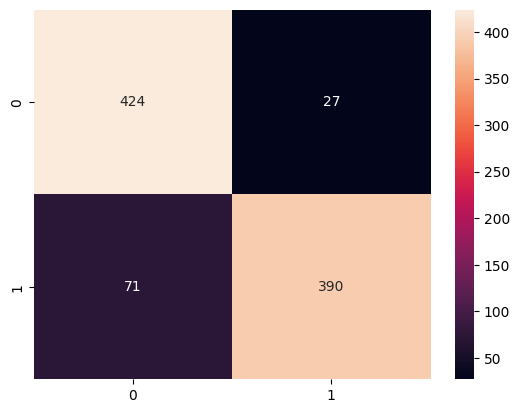

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.94      0.90       451
        True       0.94      0.85      0.89       461

    accuracy                           0.89       912
   macro avg       0.90      0.89      0.89       912
weighted avg       0.90      0.89      0.89       912

